Hello Mr. Rooney, I'm reaching out to you today because I have insight on prospective players you could look into so the Wizards are able to make it to the playoffs without breaking the bank! I acquired this listing through the use of data science and I would love to show you how I went about this.

To start, I merged two datasets. One features NBA performance statistics while the other focuses on the salaries these NBA players acquire. I figured merging these datasets would allow us to look into each player's performance statistics as well as their corresponding salaries, enabling us to find players that might peak your interest, especially if they are undervalued but their performance is pretty good. This would significantly improve the wizards chances of acquiring high performance players at reasonable salaries. I merged these two datasets by player name which enabled me to identify each player in both datasets by their salaries and performance stats.

Though these datasets were merged, to utilize the info within them I had to clean it. To do this I first dropped duplicated values found in the “Player” column of my merged dataset to ensure no player names appeared twice. I then went on to drop values I deemed unnecessary in determining a player's performance, such as row number and age, as I viewed these as not contributing anything significant to the data compared to performance stats such as team, games played, rebounds, assists, etc. Essentially, I kept features I believed would help us analyze a player's potential.

Next, I utilized a method known as clustering which is used to group data without clear labels or structure, we call this type of data unsupervised. Since our data was made up of two distinct datasets, in order to determine each player's performance statistics compared to salaries we had to cluster our features. To do this, all our data must be the same data type. Examples of data types are integers which many know to be whole numbers and strings which is anything with words, such as labels and names. Since the majority of our data is numeric we had to ensure all features being utilized were numeric. I realized that all but one column, which was the “2025-26” salary column, were already numeric, so I only had to convert the salary column. Within the clustering algorithm, we are essentially trying to guess how many clusters will allow us to easily group the data. Since we have nothing to begin with we can make a best guess estimate. I decided to set my initial number of clusters to 4, represented as k=4 and then used Standard Scaler, a method used to put all features on the same scale. Standard Scaler works by converting features to z-scores with the mean = 0 and standard deviation = 1. After scaling, I used a KMeans model to fit the data. I then assigned cluster labels to track which cluster each player was assigned to, storing this information back in the dataframe so it could be easily accessed later.
To give you some insight into what KMeans is, t is essentially a clustering model where we create a model, which was previously mentioned, and this model is used to group players into clusters based on similarities while trying to get each data point as close to the center of its cluster as possible. After running my model with 4 clusters (k=4) as my initial estimate, I visualized my findings using a scatter plot of points scored versus salary. Remember, the whole point of KMeans is to keep reassigning data points to clusters until it eventually evens out and there's no more changes
To evaluate the quality of my clustering I went on to calculate the total variance (aka inertia), which measures how close points are to their centroid (average of cluster) and how packed they are within this cluster. The silhouette score does the same thing as well, but it also measures how separated clusters are from each other, so the distance between clusters and the distance within clusters.

Next, I used the elbow method, to run KMeans across a range of k values (2-9) to plot the inertia for each value. Essentially we are looking for where the line bends to find the best k value. Looking at the plot, I determined that k = 3 would be a much better fit than my initial k=4 so went on to retrain and reevaluate. I also used the silhouette score to help determine each (data point) players fit in their cluster compared to others.




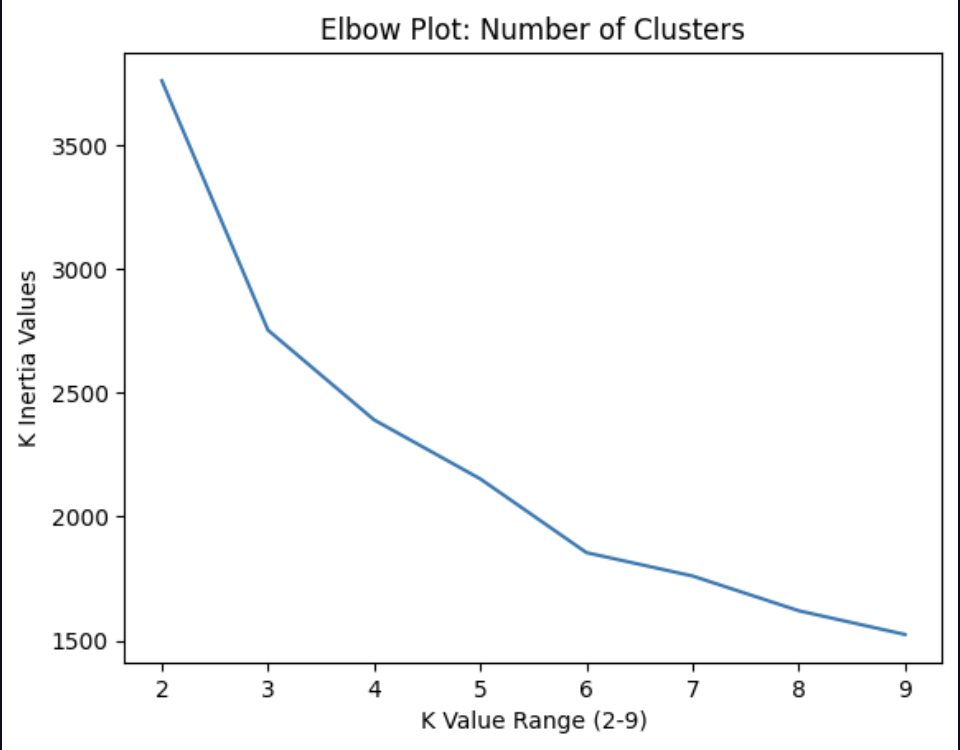

In [1]:
from IPython.display import Image
Image(filename='Elbow_method.png')

After retraining with k = 3, though my initial inertia was 2391, after retraining it now came out to 2754 with k=3. With fewer clusters, the increase in inertia was expected. However my silhouette score increased going from an initial value of 0.340 to 0.396, with this improvement confirming k=3 was the right choice for my data.


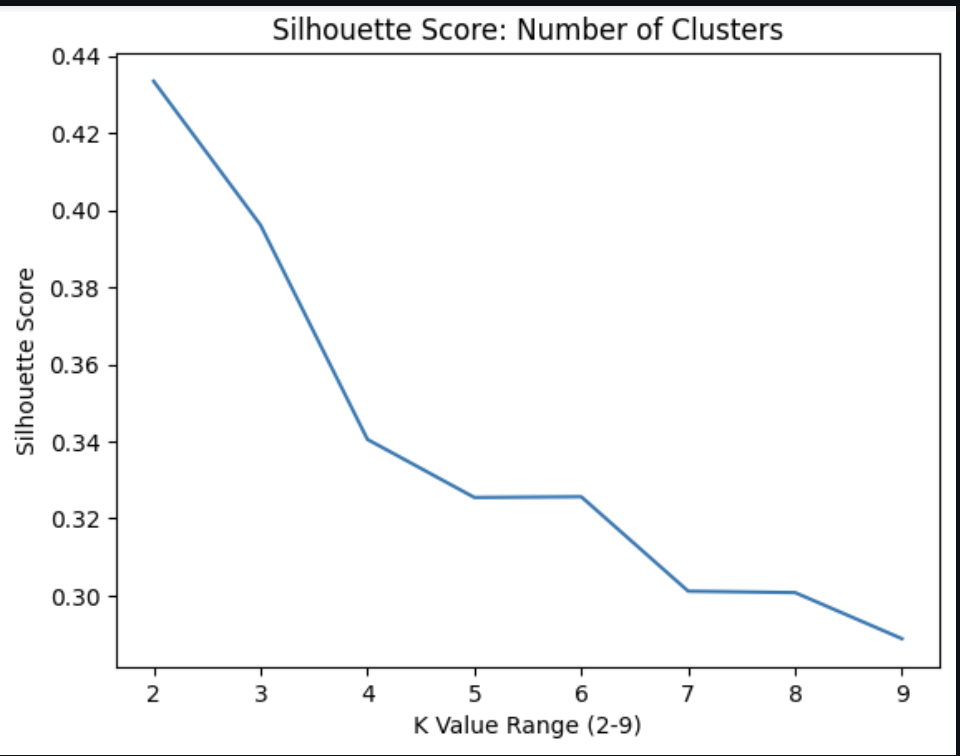

In [2]:
from IPython.display import Image
Image(filename='silhouette_score.png')


The results of the data led me to conclude that the best choices the Wizards could aim to acquire are Saddiq Bey, who has managed to score 811 points while only being offered a salary of $6M, Tim Hardaway Jr. with 763 points for just $2.3M, and Jaylon Tyson who has 693 points with a salary of $3.5M. These players could offer great value to the Wizards along with their cost.
Choices the Wizards should not consider are James Harden, who has managed to acquire a salary of $39M while only scoring 58 points, CJ McCollum who has accumulated 299 points for $30M, and Jaren Jackson Jr. who is way too expensive at $35M for an output of only 67 points. Could these players help the Wizards, sure; however they are simply not worth it.
Finally, if the Wizards were willing to stretch their pockets, they could consider players like Shai Gilgeous-Alexander, who is considered an elite with 1558 points but costs a whopping $38M, Tyrese Maxey with 1503 points and a salary of $37M, and Donovan Mitchell who outputs 1478 points but requires a salary of $46M. Though these are extremely high quality players, they come at a significant financial risk and as the Wizards aim to succeed this amy not be the time to take on these players.